<a href="https://colab.research.google.com/github/applechotiwat12/diffusion-learning/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab! diffusion-learning

Project

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image, load_digits
from sklearn.decomposition import PCA

# library พวกนี้มีติดมากับ Colab อยู่แล้ว ไม่ต้อง pip install
print("พร้อมแล้ว ✅")

พร้อมแล้ว ✅


In [44]:
# โหลดภาพตัวอย่าง (เป็นภาพสีจริง ๆ มีติดมากับ sklearn)
img = load_sample_image("flower.jpg")
print("ภาพนี้เก็บเป็น array, dtype =", img.dtype)

# ลองดูค่าตัวเลขมุมซ้ายบน 3x3 ของ channel แรก (R) — จะเห็นว่ามันคือ "เมทริกซ์ของตัวเลข"
print("ตัวอย่างค่า pixel (มุมซ้ายบน, channel R):")
print(img[:3, :3, 0])

ภาพนี้เก็บเป็น array, dtype = uint8
ตัวอย่างค่า pixel (มุมซ้ายบน, channel R):
[[2 3 7]
 [1 3 7]
 [2 6 7]]


In [45]:
# TODO 1: ภาพนี้มี shape อะไร? (height, width, channels)
# hint: ใช้ .shape
img_shape = img.shape        # <-- เติมตรงนี้
print("shape:", img_shape)

# TODO 2: ถ้า flatten ภาพนี้เป็น vector เดียว จะมีกี่มิติ (D)?
# hint: D = height * width * channels  → คูณเอง หรือใช้ np.prod(img.shape)
D = np.prod(img.shape)                # <-- เติมตรงนี้
print("จำนวนมิติของ vector (D) =", D)

# TODO 3: flatten ภาพให้กลายเป็น vector 1 มิติ
# hint: .reshape(-1)  หรือ  .flatten()
img_vector = img.reshape(-1)     # <-- เติมตรงนี้
print("shape หลัง flatten:", img_vector.shape)

shape: (427, 640, 3)
จำนวนมิติของ vector (D) = 819840
shape หลัง flatten: (819840,)


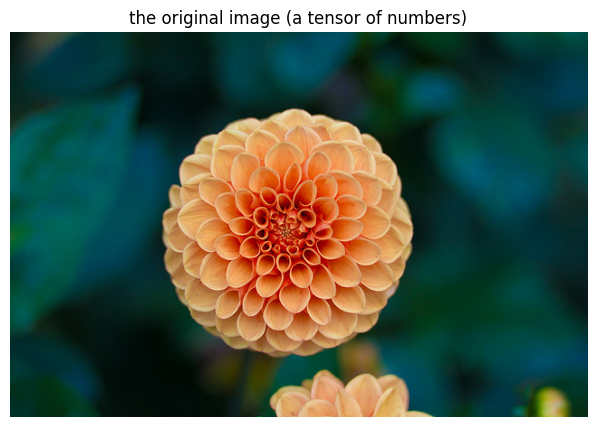

In [46]:
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis("off")
plt.title("the original image (a tensor of numbers)")
plt.show()


In [47]:
# normalize ภาพให้อยู่ในช่วง [0, 1] ก่อน (จะ plot ง่ายและบวก noise ได้เนียน)
img_norm = img / 255.0
print("ค่า min/max หลัง normalize:", img_norm.min(), img_norm.max())

ค่า min/max หลัง normalize: 0.0 1.0


In [48]:
from numpy.random import normal
# TODO 4: เขียนฟังก์ชันเติม Gaussian noise ให้ภาพ
#   แนวคิด:  noisy = image + noise,   โดย noise ~ Normal(mean=0, std=sigma)
def add_noise(image, sigma):
    # hint: np.random.normal(0, sigma, size=image.shape)
    noise = np.random.normal(0, sigma, size=image.shape)         # <-- เติมตรงนี้
    noisy = image + noise         # <-- เติมตรงนี้ (image + noise)
    return np.clip(noisy, 0, 1)   # clip ให้ยังอยู่ใน [0,1] เพื่อให้ plot สวย

# ทดสอบเร็ว ๆ
test = add_noise(img_norm, 0.2)
print("ผ่าน ✅" if test.shape == img_norm.shape else "shape ยังไม่ถูก ลองใหม่")

ผ่าน ✅


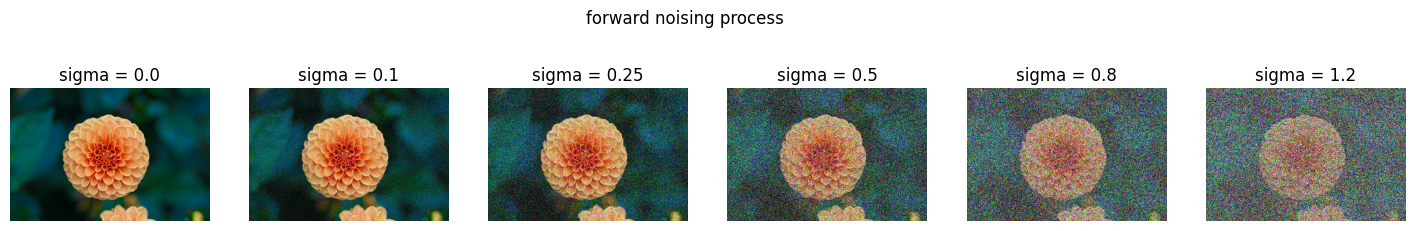

In [49]:
# cell นี้เติมให้แล้ว — plot ภาพที่ noise เพิ่มขึ้นเรื่อย ๆ
sigmas = [0.0, 0.1, 0.25, 0.5, 0.8, 1.2]
fig, axes = plt.subplots(1, len(sigmas), figsize=(18, 3))
for ax, s in zip(axes, sigmas):
    ax.imshow(add_noise(img_norm, s))
    ax.set_title(f"sigma = {s}")
    ax.axis("off")
plt.suptitle("forward noising process")
plt.show()


In [50]:
# โหลดชุดภาพ digits (เติมให้แล้ว)
digits = load_digits()
X = digits.data        # (1797, 64) — แต่ละแถวคือ 1 ภาพที่ flatten เป็น vector 64 มิติ
y = digits.target      # ป้ายกำกับว่าเป็นเลขอะไร (0-9)
print("X shape:", X.shape, "| ภาพ 1 ภาพมี", X.shape[1], "มิติ")


X shape: (1797, 64) | ภาพ 1 ภาพมี 64 มิติ


In [51]:
# TODO 5: ใช้ PCA ลดมิติจาก 64 → 2 เพื่อเอาไป plot
# hint: PCA(n_components=2).fit_transform(X)
X_2d = PCA(n_components=2).fit_transform(X)          # <-- เติมตรงนี้
print("หลัง PCA:", X_2d.shape)   # ควรได้ (1797, 2)

หลัง PCA: (1797, 2)


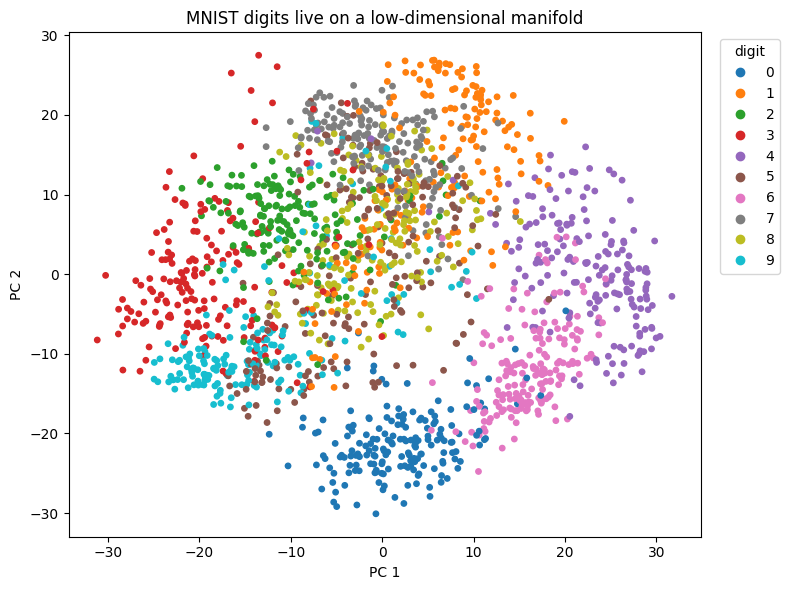

In [52]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="tab10", s=15)
plt.legend(*sc.legend_elements(), title="digit", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.title("MNIST digits live on a low-dimensional manifold")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.tight_layout()
plt.show()


In [53]:
# (ออปชัน) TODO 6: PCA 2 แกนแรกอธิบาย variance ได้กี่ %?
# hint: สร้าง PCA แล้วดู .explained_variance_ratio_
pca = PCA(n_components=2).fit(X)
print("variance ที่อธิบายได้:", pca.explained_variance_ratio_)
print("รวม 2 แกนแรก:", pca.explained_variance_ratio_.sum())

variance ที่อธิบายได้: [0.14890594 0.13618771]
รวม 2 แกนแรก: 0.28509364823699285


In [54]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")